# Artitech: Adaptive Artwork Recommendation System

**Goal:** This notebook demonstrates an adaptive Retrieval-Augmented Generation (RAG) system combined with an artwork recommender. The system aims to provide empathetic responses and relevant artwork suggestions based on user input and detected emotions.

**Core Components:**
*   **Artwork Recommender:** Uses CLIP embeddings and color analysis to find artworks related to emotions. (`src/artwork_recommender.py`, `src/recommender_setup.py`)
*   **Adaptive RAG Graph:** Uses LangGraph to dynamically route user queries based on context, relevance, and emotion. (`src/graph_builder.py`, `src/graph_nodes.py`, `src/emotion_nodes.py`)
*   **Data Processing:** Loads and prepares text data (PDFs) and artwork data (CSV, images). (`src/data_processing.py`)
*   **LangChain Components:** Leverages various LangChain elements for prompting, retrieval, grading, and chaining. (`src/chain.py`, `src/prompts.py`, `src/grading.py`, etc.)

## 1. Setup and Initialization

This section handles importing necessary libraries, setting up API keys, and configuring application settings.

In [7]:
# 필요한 패키지 설치
!pip install -q langchain langchain-community langchain-openai
!pip install -q chromadb
!pip install -q python-dotenv
!pip install -q langgraph
!pip install -q tavily-python
!pip install -q pypdf
!pip install -q langchain-core
!pip install -q langchain-experimental
!pip install -q pandas numpy
!pip install -q langchain-huggingface
!pip install -q langchain-elasticsearch
!pip install -q graphviz
!pip install -q langchain-teddynote
!pip install --upgrade --force-reinstall urllib3
!pip install -q faiss-cpu

  Using cached urllib3-2.4.0-py3-none-any.whl.metadata (6.5 kB)
Using cached urllib3-2.4.0-py3-none-any.whl (128 kB)
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.4.0
    Uninstalling urllib3-2.4.0:
      Successfully uninstalled urllib3-2.4.0


### 1.1 API Key Configuration

We need to set up API keys for OpenAI and potentially other services like Tavily Search. The `fix_api_key.py` script helps manage this process, attempting to load keys from a `.env` file or using predefined values if necessary.

In [8]:
import os
from dotenv import load_dotenv

os.chdir('/Users/ijunhyeong/Desktop/Artitech_Final')
print(f"Current working directory: {os.getcwd()}")
print("Current working directory:", os.getcwd())
print("Files in directory:", os.listdir())

load_dotenv()

Current working directory: /Users/ijunhyeong/Desktop/Artitech_Final
Current working directory: /Users/ijunhyeong/Desktop/Artitech_Final
Files in directory: ['.DS_Store', 'emotion_art_cache', 'adaptive_chat_interface.py', 'graph.py', '.env', 'artitech_final.ipynb', 'scripts', 'data', 'src']


True

In [9]:
# fix_api_key.py에서 함수 가져오기
from scripts.fix_api_key import fix_openai_api_key
from scripts.fix_api_key import fix_tavily_api_key

# OpenAI API 키 설정
openai_api_key = fix_openai_api_key()

# Tavily API 키 설정 (필요한 경우)
tavily_api_key = fix_tavily_api_key()


OpenAI API Key has been set: sk-proj-Gc...
Loaded environment from /Users/ijunhyeong/Desktop/Artitech_Final/.env
Found valid TAVILY_API_KEY in .env: tvly-dev-o...
Tavily API Key has been set: tvly-dev-o...


In [10]:
LANGSMITH_PROJECT = "ArtiTech_ver1"

In [11]:
from langchain_teddynote import logging

# Start tracking the langsmith
logging.langsmith("ArtiTech_Final")

LangSmith 추적을 시작합니다.
[프로젝트명]
ArtiTech_Final


## 2. Data Loading and Preparation

Here, we load the necessary data for both the RAG system (text documents) and the artwork recommender (artwork metadata and images).

### 2.1 Loading and Splitting Text Documents

We use functions from `src/data_processing.py` to load PDF documents from a specified directory. These documents are then split into smaller chunks using an adaptive strategy based on document length. This is crucial for efficient retrieval in the RAG system.

### 2.2 Initializing Embeddings Model

We need an embedding model (e.g., from OpenAI) to convert text chunks into vector representations for similarity search.

In [12]:
# Cell: Load Data and Create Retriever
from langchain_openai import OpenAIEmbeddings
from src.data_processing import load_and_split_pdfs
from src.retriever import create_ensemble_retriever

# 데이터 디렉토리 설정
DATA_DIR = "data/RAG_pdf"

# 1. Load and split documents
split_documents = load_and_split_pdfs(DATA_DIR)

# 2. Initialize embeddings
embeddings = OpenAIEmbeddings()

Total 14 pdf files found.
'13.Art therapy and neuroscience.pdf'에서 6 페이지를 로드했습니다.
'6.Elements_of_art.pdf'에서 3 페이지를 로드했습니다.
'14.Formal_Elements_of_Art_Products.pdf'에서 13 페이지를 로드했습니다.
'10.Colour_Psychology_in_Art.pdf'에서 8 페이지를 로드했습니다.
'7.verywellmind.com.pdf'에서 4 페이지를 로드했습니다.
'11.Study_on_Color_Art_Therapy_Techniques.pdf'에서 21 페이지를 로드했습니다.
'3.Color_Psychology_Effects_of_Perceiving_Color_on_Psychological_Functioning_in_Humans.pdf'에서 29 페이지를 로드했습니다.
'2.Final-Over-60-Art-Therapy-Exercises.pdf'에서 62 페이지를 로드했습니다.
'1.psychological-effects-of-colour.pdf'에서 2 페이지를 로드했습니다.
'12.Visual_Symbolization.pdf'에서 9 페이지를 로드했습니다.
'5.Understanding_Formal_Analysis.pdf'에서 3 페이지를 로드했습니다.
'4.Art_and_Design_Foundation_LM_Section-6_LV.pdf'에서 26 페이지를 로드했습니다.
'9.Art_Projects_in_Therapy_Kids_First.pdf'에서 9 페이지를 로드했습니다.
'8.Brushing Away Stress_ 21 Art Therapy Activities for Self-Expression and Healing - RMCAD.pdf'에서 11 페이지를 로드했습니다.
총 206 pages loaded.
적응형 분할 방식으로 문서를 926 청크로 분할했습니다.


## 3. Retrieval-Augmented Generation (RAG) Components

Now, we set up the individual components required for the adaptive RAG workflow. These components will be assembled into a graph later.

### 3.1 Creating the Retriever

We create an `EnsembleRetriever` (using `src/retriever.py`) which combines:
1.  **FAISS Retriever:** For dense vector similarity search based on semantic meaning.
2.  **BM25 Retriever:** For sparse, keyword-based search.

This hybrid approach often yields better results than using either method alone.

In [13]:
# 3. Create the ensemble retriever
# Ensure split_documents is not empty before proceeding
if split_documents:
    ensemble_retriever = create_ensemble_retriever(split_documents, embeddings, k=5)
else:
    print("Error: No documents were loaded or split. Cannot create retriever.")
    # Handle the error appropriately, maybe raise an exception or exit
    ensemble_retriever = None

Ensemble (Hybrid) retriever created.


In [14]:
# Cell: Test Retriever (Optional)
if ensemble_retriever:
    test_query = "I really had a bad day today. What color can heal my mood?"
    # Use invoke instead of get_relevant_documents
    test_retrieved_docs = ensemble_retriever.invoke(test_query)
    print(f"Retrieved {len(test_retrieved_docs)} documents for test query:")
    for i, doc in enumerate(test_retrieved_docs):
        print(f"--- Doc {i+1} (Source: {doc.metadata.get('source', 'N/A')}, Page: {doc.metadata.get('page', 'N/A')}) ---")
        print(doc.page_content[:200] + "...") # Print start of content
    else:
        print("Retriever not created, skipping test.")

Retrieved 10 documents for test query:
--- Doc 1 (Source: data/RAG_pdf/7.verywellmind.com.pdf, Page: 3) ---
1. Carsley D, Heath N. Eﬀectiveness of mindfulness-based colouring for test anxiety in
adolescents. Sch Psychol Int. 2018;39(3):251-272. doi:10.1177/0143034318773523
2. Bell, Chloe E.; Robbins, Steven...
--- Doc 2 (Source: data/RAG_pdf/10.Colour_Psychology_in_Art.pdf, Page: 1) ---
A. R. Hussain 
 
 
DOI: 10.4236/adr.2021.94025 302 Art and Design Review 
 
steeped in colour, shaping how we interpret matter (particles and fields). Colour 
continually surrounds us and mediates our...
--- Doc 3 (Source: data/RAG_pdf/10.Colour_Psychology_in_Art.pdf, Page: 3) ---
A. R. Hussain 
 
 
DOI: 10.4236/adr.2021.94025 304 Art and Design Review 
 
viewing the work) to those the artist felt (in producing it). Hence it is useful to 
make a distinction: bet ween the effect...
--- Doc 4 (Source: data/RAG_pdf/8.Brushing Away Stress_ 21 Art Therapy Activities for Self-Expression and Healing - RMCAD.pd

### 3.2 Defining Prompts

Prompts guide the behavior of the LLM. We define several key prompts in `src/prompts.py`:
*   `prompt_template`: The main conversational prompt defining the AI's persona and response structure.
*   `rewrite_prompt`: Used to rephrase user questions for better retrieval.
*   `citation_prompt`: Used for enforcing citation generation (though may not be directly used in the final graph's generation steps if the main prompt handles it).

In [15]:
from src.chain import prepare_rag_input, create_og_chain
from src.prompts import prompt_template # Import your prompt
from langchain_openai import ChatOpenAI # To define the llm

llm = ChatOpenAI(model_name="gpt-4o", temperature=0)

In [16]:
if 'llm' in locals() and 'prompt_template' in locals():
    og_chain_modular = create_og_chain(llm, prompt_template)
    print("Modular OG Chain created successfully.")

Modular OG Chain created successfully.


In [17]:
# Define the Retriever (ensure 'ensemble_retriever' exists from previous cells)
if 'ensemble_retriever' in locals():
    # Prepare input using the helper function
    test_question = "Please guide me through a simple art activity to help my relax. I am interested in it."
    input_data = prepare_rag_input(test_question, ensemble_retriever) # Uses the helper from src/chain.py

    # Invoke the chain
    response = og_chain_modular.invoke(input_data)
    print("\n----- Modular OG Chain Response -----")
    print(response)
else:
    print("Error: 'ensemble_retriever' not defined. Cannot test the chain.")

Prepared context for query: 'Please guide me through a simple art activity to help my relax. I am interested in it.' using 10 documents.

----- Modular OG Chain Response -----
Hello there! I'm glad you're interested in using art to relax. Art can be a wonderful way to unwind and express yourself. 😊

One simple and calming activity you might enjoy is creating a "Stone Mandala." This involves gathering some stones and arranging them into a mandala pattern. The focus here is on the calming process of placing the stones rather than the final arrangement. This activity can help you find a sense of tranquility and mindfulness as you concentrate on the gentle, repetitive action. [Source: data/RAG_pdf/9.Art_Projects_in_Therapy_Kids_First.pdf, Page 2]

If you have any stones or pebbles around, give it a try! Let me know how it goes or if you have any other questions. 🌟


### 3.3 Creating Grader Chains

Graders are LLM chains used to evaluate intermediate results within the RAG flow (`src/grading.py`):
*   **Retrieval Grader:** Assesses if a retrieved document is relevant to the question.
*   **Hallucination Grader:** Checks if the generated answer is grounded in the provided documents.
*   **Answer Grader:** Evaluates if the generated answer actually addresses the user's question.

These graders output structured data (Pydantic models) for reliable decision-making in the graph.

In [18]:
from langchain_openai import ChatOpenAI # To define the llm

# --- Import Creator Functions ---
from src.routing import create_question_router
from src.grading import create_retrieval_grader, create_hallucination_grader, create_answer_grader
from src.rewriting import create_question_rewriter 
# ------------------------------

# --- Initialize LLM --- 
llm = ChatOpenAI(model_name="gpt-4o", temperature=0)
# ----------------------

# --- Initialize Router and Graders --- 
question_router = create_question_router(llm)
retrieval_grader = create_retrieval_grader(llm)
hallucination_grader = create_hallucination_grader(llm)
answer_grader = create_answer_grader(llm)
question_rewriter = create_question_rewriter(llm)

print("LLM, Router, and Graders Initialized.")
# -------------------------------------

LLM, Router, and Graders Initialized.


## 4. Artwork Recommender System

This section focuses on setting up the `ArtworkRecommender`, which finds relevant artworks based on emotional prompts.

### 4.1 Initializing the Recommender

The `initialize_recommender` function (from `src/recommender_setup.py`) encapsulates the setup process for the `ArtworkRecommender` class (defined in `src/artwork_recommender.py`). This involves:
*   Loading the specified CLIP model (`openai/clip-vit-large-patch14` by default).
*   Loading artwork metadata from the CSV (`config.CSV_PATH`).
*   Checking for corresponding images (`config.IMAGE_FOLDER`).
*   Generating or loading cached image embeddings (`config.CACHE_DIR`).
*   Optionally building a FAISS index for faster search if FAISS is available (`config.FAISS_AVAILABLE`).

In [19]:
# Cell: Initialize Artwork Recommender and Load Data
import os
import sys

# Use the explicitly set working directory or dynamically find project root
project_root = '/Users/ijunhyeong/Desktop/Artitech_Final' # Please rename this with your project_root.
src_dir = os.path.join(project_root, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
print(f"Ensured '{src_dir}' is in sys.path")

# --- Import setup function and initialize ---
try:
    # --- Add reload logic if kernel restart isn't sufficient ---
    import importlib
    import src.config
    import src.recommender_setup
    importlib.reload(src.config)
    importlib.reload(src.recommender_setup)
    # --- End reload logic ---

    from src.recommender_setup import initialize_recommender
    from src.display_utils import display_recommendations # Keep display utils import separate if used later
    from src.config import IN_NOTEBOOK # Import config needed for display

    # Set rebuild_cache=True if you need to regenerate embeddings
    recommender = initialize_recommender(rebuild_cache=False)

    if recommender:
        print("Artwork Recommender initialized successfully.")
    else:
        print("Artwork Recommender initialization failed.")

except ImportError as e:
    print(f"ImportError: {e}")
    print("Please ensure 'src' directory is correct and dependencies are installed.")
    recommender = None # Ensure recommender is None if import fails
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    recommender = None # Ensure recommender is None on other errors

Ensured '/Users/ijunhyeong/Desktop/Artitech_Final/src' is in sys.path
Using font: AppleGothic for CJK character support
Using font: AppleGothic for CJK character support
Initializing ArtworkRecommender with model: openai/clip-vit-large-patch14
Using device: mps
Loading CLIP model: openai/clip-vit-large-patch14
Attempting to load dataset from CSV: data/art_csv/painting_info_with_descriptions.csv and Images: data/images
Loading CSV from: data/art_csv/painting_info_with_descriptions.csv
Checking if images exist in data/images...


Checking images: 100%|██████████| 5286/5286 [00:00<00:00, 467833.36it/s]


Found 21 images out of 5286 records
Loaded 21 artworks with images
Loading cached embeddings from emotion_art_cache/image_embeddings_8283e7079c.pkl
Loaded 21 cached embeddings
All required embeddings found in cache.
Embedding dimension set from cache: 768
Creating FAISS index with dimension 768


Building FAISS index: 100%|██████████| 21/21 [00:00<00:00, 29547.26it/s]

Created FAISS index with 21 vectors
Dataset loaded successfully. Recommender ready.
Total artworks loaded: 21
FAISS index active with 21 items.
Artwork Recommender initialized successfully.


\n--- Example Recommendation ---
Generated prompt: 'An artwork that expresses the emotion of Love. It might contain couples, embrace, mother and child. In a style that is Romanticism, Warm lighting. Using colors like Red, Pink, Warm Beige.'
Using FAISS for similarity search.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


\nDisplaying top 3 recommendations for 'Love':

🎨 Recommendation #1
📌 Title: The Nativity
👩‍🎨 Artist: Francesco di Giorgio Martini
🖌️  Medium: Tempera on wood
📅 Created: Unknown
🏛️  Style/Classification: Paintings
🎨 Dominant Colors: Charcoal Gray, Dusty Brown, Off-White
✨ Match Score: 18.7%

📝 Description:
  The Nativity is a Unknown Painting by the Unknown artist Francesco di Giorgio Martini. This piece, part of the European Paintings collection, is crafted using Tempera on wood. Measuring Overall 20 3/4 x 23 5/8 in. (52.7 x 60 cm); painted surface 20 1/2 x 22 1/2 in. (52.1 x 57.2 cm); painted surfa...

💭 Why this artwork for your emotion?
  • Its overall visual qualities align with feelings of Love.
  • It visually matches our 'Love' prompt reasonably well (19%).
------------------------------------------------------------


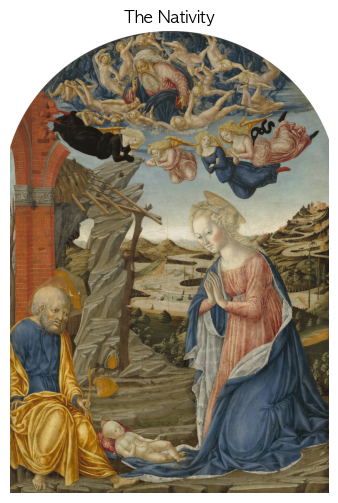




🎨 Recommendation #2
📌 Title: Madonna and Child with Angels
👩‍🎨 Artist: Gentile da Fabriano (Gentile di Niccolò di Giovanni di Massio)
🖌️  Medium: Tempera on wood, traces of gold ground
📅 Created: Unknown
🏛️  Style/Classification: Paintings
🎨 Dominant Colors: Dusty Brown, Charcoal Gray, Charcoal
✨ Match Score: 18.5%

📝 Description:
  Madonna and Child with Angels is a Unknown Painting by the Unknown artist Gentile da Fabriano (Gentile di Niccolò di Giovanni di Massio). This piece, part of the European Paintings collection, is crafted using Tempera on wood, traces of gold ground. Measuring 33 3/4 x 20 in. (85.7 x 50.8 cm), the...

💭 Why this artwork for your emotion?
  • Its overall visual qualities align with feelings of Love.
  • It visually matches our 'Love' prompt reasonably well (19%).
------------------------------------------------------------


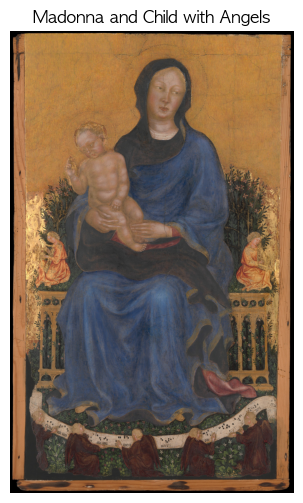




🎨 Recommendation #3
📌 Title: Apples
👩‍🎨 Artist: Paul Cézanne
🖌️  Medium: Oil on canvas
📅 Created: 1878–79
🏛️  Style/Classification: Paintings
🎨 Dominant Colors: Moss, Charcoal, Olive
✨ Match Score: 17.3%

📝 Description:
  Apples is a Unknown Painting by the Unknown artist Paul Cézanne. This piece, part of the European Paintings collection, is crafted using Oil on canvas. Measuring 9 x 13 in. (22.9 x 33 cm), the work is classified as Paintings and was created in 1878–79.

💭 Why this artwork for your emotion?
  • Its overall visual qualities align with feelings of Love.
  • It visually matches our 'Love' prompt reasonably well (17%).
------------------------------------------------------------


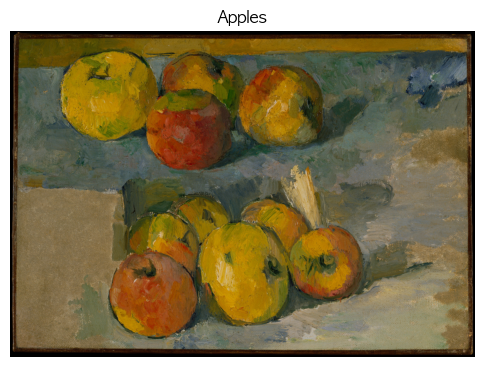

In [20]:
# Example Usage (Optional)
if recommender:
     print("\\n--- Example Recommendation ---")
     test_emotion = "Love"
     recommendations_df, similarities = recommender.get_recommendations(test_emotion, top_n=3)

     if recommendations_df is not None:
         print(f"\\nDisplaying top {len(recommendations_df)} recommendations for '{test_emotion}':")
         # Decide whether to display images based on environment
         display_recommendations(recommendations_df, similarities, display_images=IN_NOTEBOOK)
     else:
         print(f"Could not get recommendations for '{test_emotion}'.")

## 5. Building the Adaptive RAG Graph

We use LangGraph to define the application's control flow as a state machine.

### 5.1 Graph State

The `GraphState` TypedDict (defined in `src/state.py`) holds all the data passed between nodes in the graph, including the question, documents, generation, conversation history, emotion details, and art recommendation status.

### 5.2 Defining Nodes and Edges

The core logic resides in the graph nodes defined in `src/graph_nodes.py` and `src/emotion_nodes.py`. The `create_adaptive_rag_graph` function in `src/graph_builder.py` assembles these nodes and defines the conditional edges that control the flow based on the current state (e.g., relevance grades, detected emotion).

Key steps in the graph include:
1.  **Routing:** Initial routing based on user input type (memory, web, vectorstore, art request).
2.  **Retrieval & Grading:** Fetching and filtering relevant documents.
3.  **Generation & Hallucination Check:** Generating an answer and ensuring it's grounded.
4.  **Emotion Detection:** Analyzing the user's query/context for emotion.
5.  **Art Suggestion/Recommendation:** Conditionally suggesting or displaying artwork based on emotion and user preference.

In [21]:
# Cell: Define and Compile LangGraph Workflow

# Required imports for graph components (keep necessary ones here if used outside graph creation)
# from langgraph.graph import END, StateGraph, START # Moved to graph_builder
from langgraph.checkpoint.memory import MemorySaver # Needed here to create checkpointer
# from src.state import GraphState # Moved to graph_builder

# --- Import the graph builder function ---
# from src.graph_builder import create_adaptive_rag_graph # Moved below reload

# --- Create checkpointer ---
checkpointer = MemorySaver()

# --- Build the graph ---
try:
    # Ensure sys.path includes src and scripts if needed for imports within graph_builder
    # (The sys.path manipulation should ideally happen in an earlier cell)
    import importlib
    import src.graph_builder
    # Also reload dependencies if they changed
    try:
        import src.state
        importlib.reload(src.state)
    except ImportError: pass # Ignore if state module doesn't exist or fails
    try:
        import src.graph_nodes
        importlib.reload(src.graph_nodes)
    except ImportError: pass 
    # Ignore if nodes module doesn't exist or fails
    # Reloading scripts might be tricky, ensure they are stable or moved to src
    # try:
    #     import scripts.emotion.multi_turn_router
    #     importlib.reload(scripts.emotion.multi_turn_router)
    #     # ... reload other script dependencies ...
    # except ImportError: pass

    importlib.reload(src.graph_builder) # Reload the builder itself
    from src.graph_builder import create_adaptive_rag_graph # Re-import after reload

    adaptive_rag = create_adaptive_rag_graph(checkpointer=checkpointer)
    print("Graph compilation triggered from notebook.")
except ImportError as e:
    print(f"ImportError during graph creation: {e}")
    print("Check imports within src/graph_builder.py and ensure necessary modules (like src.state, src.graph_nodes, and potentially scripts) are accessible.")
    adaptive_rag = None
except Exception as e:
    print(f"An unexpected error occurred during graph creation: {e}")
    adaptive_rag = None

Adaptive RAG Graph Compiled.
Graph compilation triggered from notebook.


In [22]:
import langgraph
from langchain_teddynote.graphs import visualize_graph

# Visualize the graph
langgraph.graph.graph.TIMEOUT = 60  # Increase to 60 seconds
visualize_graph(adaptive_rag)

[ERROR] Visualize Graph Error: HTTPSConnectionPool(host='mermaid.ink', port=443): Read timed out. (read timeout=10)


## 6. Running the Application

Now we can interact with the compiled LangGraph application. We invoke it with the user's query and a configuration dictionary specifying the thread ID for maintaining conversation state.

### 6.1 Invoking the Graph

We send the input question to the graph's stream or invoke method. The `config` dictionary is crucial for tracking conversational memory using the checkpointer.

In [23]:
# Import the utility functions for running the graph
#from graph_utils import print_graph_structure
from langchain_core.runnables import RunnableConfig
# Configure the inputs
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": "test_run"})

# Test Case 1: Direct art request
inputs1 = {
    "question": "I'm feeling really sad today after receiving some bad news",
}

# Run the graph with the direct art request
print("===== Test Case 1: Direct Art Request =====")
result1 = adaptive_rag.invoke(inputs1, config)

# --- Add this part ---
# Extract the relevant messages from the result state
rag_answer = result1.get("generation", "")
suggestion_offer = result1.get("suggestion_message", "")

# Combine and print the desired output for the user
full_response = f"{rag_answer}\n\n{suggestion_offer}".strip()
print("\n--- AI Response (Turn 1) ---")
print(full_response)
print("---------------------------\n")


===== Test Case 1: Direct Art Request =====
==== [LLM-Based Multi-Turn Router] ====
No pending suggestion. Classifying user intent.
LLM Router Intent: standard_query
==== [Node: web_search] ====
==== [Node: generate_answer_websearch] ====
==== [Node: emotion_detect_grader] ====
==== [Node: emotion_detect_node (from src)] ====
Attempting to identify specific emotion.
✓ Directly Detected: sadness (Confidence: 0.90)
✓ Emotion Detected: sadness (Confidence: 0.90)
---- ROUTING ART SUGGESTION ----
LLM Router Decision (stripped): suggest_art
ART_SUGGESTION_ROUTER: Returning valid decision: 'suggest_art' (Type: <class 'str'>)
==== [Art Suggestion Node] ====
Detected emotion: sadness - suggesting art recommendations
[_get_emotion_category in scripts] called with: sadness

--- AI Response (Turn 1) ---
I'm really sorry to hear that you're feeling sad today after receiving some bad news. It's completely normal to feel this way, and it's important to acknowledge those emotions. 

Art can be a wonde

### 6.2 Displaying Artwork Recommendations

If the graph generated artwork recommendations (`art_recommendations` in the state), we can use the `display_recommendations` utility from `src/display_utils.py` to show them, including images (if in a notebook environment).


===== Test Case 1: Second Turn - User Accepts Art Offer =====
==== [LLM-Based Multi-Turn Router] ====
Pending art suggestion found. Routing to process response.
==== [Processing Art Suggestion Response] ====
User accepted art suggestion
---- ROUTING ART SUGGESTION ----
LLM Router Decision (stripped): show_art
ART_SUGGESTION_ROUTER: Returning valid decision: 'show_art' (Type: <class 'str'>)
==== [Art Recommendation Node] ====
Detected Emotion: sadness
LLM suggested target emotion: Hope
Using LLM target emotion: Hope
[_map_emotion_to_art_system in scripts] called with: Hope
Mapping chosen target emotion 'Hope' to art system emotion 'Hope'
Found recommender in __main__.
Getting art recommendations for 'Hope' (Target Emotion)
Generated prompt: 'An artwork that expresses the emotion of Hope. Using colors like Sunshine Yellow, Mint, Soft Blue.'
Using FAISS for similarity search.
Found 1 recommendations for target emotion 'Hope'
==== [Displaying Art Recommendations] ====
Found display_recomm

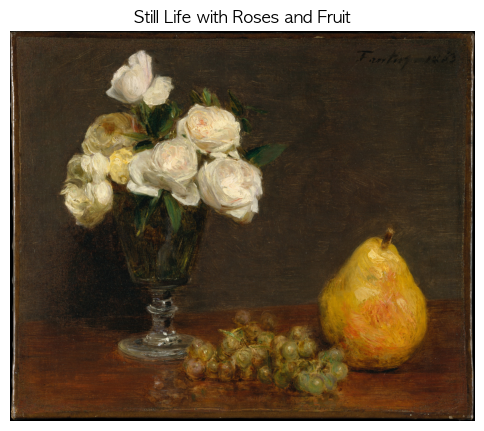



==== [Node: generate_art_explanation] ====

--- AI Response (Turn 2) ---
I hope viewing this artwork provides some comfort or perspective. Let me know if you'd like to explore other options or talk more.
---------------------------



In [24]:
user_response_turn_2 = "Yes, please show me one art that can make me feel better."

inputs2 = {
        "question": user_response_turn_2,
    }

print("\n===== Test Case 1: Second Turn - User Accepts Art Offer =====")
result2 = adaptive_rag.invoke(inputs2, config)
# --- Add this part ---
# Extract the relevant messages from the result state
final_response = result2.get("generation", "")
#suggestion_offer = result2.get("suggestion_message", "")

# Combine and print the desired output for the user
print("\n--- AI Response (Turn 2) ---")
print(final_response)
print("---------------------------\n")

In [25]:
user_response_turn_3 = "If I want to draw my own art referencing this artwork, what should I pay attention to?"

inputs3 = {
        "question": user_response_turn_3,
    }

print("\n===== Test Case 1: Second Turn - User Accepts Art Offer =====")
result3 = adaptive_rag.invoke(inputs3, config)
# --- Add this part ---
# Extract the relevant messages from the result state
rag_answer = result3.get("generation", "")
suggestion_offer = result3.get("suggestion_message", "")

# Combine and print the desired output for the user
full_response = f"{rag_answer}\n\n{suggestion_offer}".strip()
print("\n--- AI Response (Turn 3) ---")
print(full_response)
print("---------------------------\n")


===== Test Case 1: Second Turn - User Accepts Art Offer =====
==== [LLM-Based Multi-Turn Router] ====
No pending suggestion. Classifying user intent.
LLM Router Intent: standard_query
==== [Node: web_search] ====
==== [Node: generate_answer_websearch] ====
==== [Node: emotion_detect_grader] ====
==== [Node: emotion_detect_node (from src)] ====
Emotion not directly detected from list.
Using LLM to match closest emotion from list.
✓ LLM Matched: curious (Confidence: 0.70)
✓ Emotion Detected: curious (Confidence: 0.70)
---- ROUTING ART SUGGESTION ----
LLM Router Decision (stripped): skip_art
ART_SUGGESTION_ROUTER: Returning valid decision: 'skip_art' (Type: <class 'str'>)

--- AI Response (Turn 3) ---
Hey there! It's great that you're interested in drawing your own art using a reference. 😊

When you're working from a reference, it's important to pay attention to the proportions and details of the subject. For example, if you're drawing a face, notice the proportion of the parts of the fa